#### To predict whether the patient is suffering from diabetes or not based on Logistic Regression using Cross Validation 


#### Cross Validation

It is a technique of dividing the dataset into the training and validation part. Then computing the accuracy for each fold.


#### Advantages of Cross Validation:---

1.  Cross Validation reduces overfitting.

2.  It helps in providing the stability to the model.

3.  It helps in utilizing the datasets very much efficiently.


##### Step 1:  Import all the necessary libraries

In [1246]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.utils               import      resample
from    sklearn.model_selection     import      train_test_split, KFold, cross_val_score, GridSearchCV
from    sklearn.preprocessing       import      StandardScaler
from    sklearn.linear_model        import      LogisticRegression
from    sklearn.pipeline            import      Pipeline
from    sklearn.metrics             import      accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, roc_auc_score

#### Step 2: Load the Dataset

In [1247]:
#### define the url

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

### define the list of columns for the dataset
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(url, names = columns)

print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

#### OBSERVATIONS:

1.  The dataset contains the list of records for each patients and tells whether they are suffering from diabetes or not.

2.  There are total 768 records in the dataset.

3.  The independent or the input features in the dataset are from Pregnancies .... Age.

4.  The Outcome is the dependent or the output feature.

#### Step 3: Perform the Data Exploration

In [1248]:
#### get the first five rows of the dataset

print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [1249]:
#### get the last five rows of the dataset

print(df.tail())

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
763                     0.171   63        0  
764                     0.340   27        0  
765                     0.245   30        0  
766                     0.349   47        1  
767                     0.315   23        0  


In [1250]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 768


In [1251]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (768, 9)


In [1252]:
### get the columns used in the dataset

print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [1253]:
#### get the information about the columns used in the dataset

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [1254]:
### get the statistical summary about the dataset

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [1255]:
#### get the count of all the outcome categories

df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [1256]:
#### get the correlation between all the columns espicially numerical columns

df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


<Axes: >

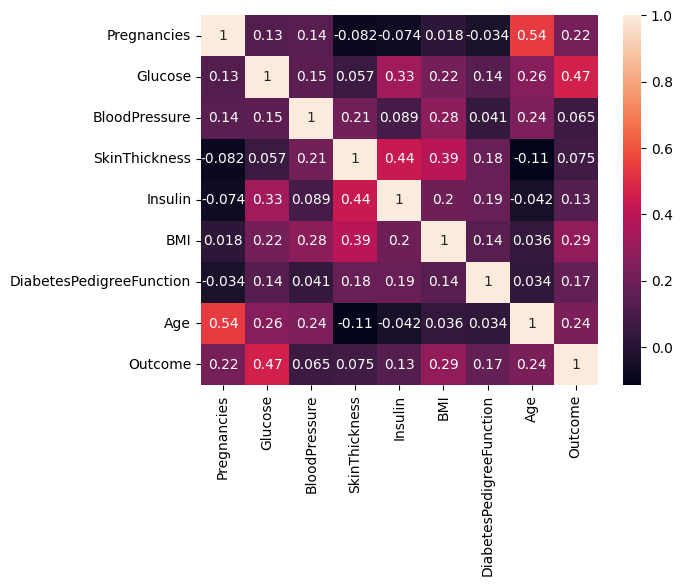

In [1257]:
#### get the graphical visualization between all the numerical columns used in the dataset

sns.heatmap(df.corr(), annot=True)

#### OBSERVATIONS:

1.  The above graph explains about the correlation between all the numerica columns in the dataset.

2.  The high correlation  is red in color while the low correlation is dark blue in color.

#### Step 4: Perform the Data Cleaning

In [1258]:
#### To check for any NULL Values in the dataset

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL values in the dataset.

In [1259]:
#### To check for the duplicate records in the dataset

df[df.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

In [1260]:
#### To make the imbalanced dataset as balanced

df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

#### OBSERVATIONS:

1.  Here we can see that the number of 1s are much less in number than the 0s

In [1261]:
#### Perform the resampling to make the imbalanced dataset as balanced

df_majority = df[df['Outcome'] == 0]

df_minority = df[df['Outcome'] == 1]

In [1262]:
df_majority

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,1,85,66,29,0,26.6,0.351,31,0
3,1,89,66,23,94,28.1,0.167,21,0
5,5,116,74,0,0,25.6,0.201,30,0
7,10,115,0,0,0,35.3,0.134,29,0
10,4,110,92,0,0,37.6,0.191,30,0
...,...,...,...,...,...,...,...,...,...
762,9,89,62,0,0,22.5,0.142,33,0
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0


In [1263]:
df_minority

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
2,8,183,64,0,0,23.3,0.672,32,1
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
...,...,...,...,...,...,...,...,...,...
755,1,128,88,39,110,36.5,1.057,37,1
757,0,123,72,0,0,36.3,0.258,52,1
759,6,190,92,0,0,35.5,0.278,66,1
761,9,170,74,31,0,44.0,0.403,43,1


In [1264]:
#### perform upsampling on the minority class

df_minority_upsample = resample(
    df_minority                                          ,
    replace             =        True                    ,
    n_samples           =       len(df_majority)         ,
    random_state        =         42
)

In [1265]:
df_new = pd.concat([df_majority, df_minority_upsample])

In [1266]:
# Shuffle
df_downsampled = df_new.sample(frac=1, random_state=42)

In [1267]:
df_downsampled['Outcome'].value_counts()

Outcome
1    500
0    500
Name: count, dtype: int64

In [1268]:
df = df_downsampled

In [1269]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
444,4,117,62,12,0,29.7,0.380,30,1
56,7,187,68,39,304,37.7,0.254,41,1
387,8,105,100,36,0,43.3,0.239,45,1
143,10,108,66,0,0,32.4,0.272,42,1
627,0,132,78,0,0,32.4,0.393,21,0
...,...,...,...,...,...,...,...,...,...
163,2,100,64,23,0,29.7,0.368,21,0
437,5,147,75,0,0,29.9,0.434,28,0
719,5,97,76,27,0,35.6,0.378,52,1
660,10,162,84,0,0,27.7,0.182,54,0


In [1270]:
#### Check the count of the Outcomes used in the dataset

df['Outcome'].value_counts()

Outcome
1    500
0    500
Name: count, dtype: int64

#### OBSERVATIONS:

1.  The dataset is now completely balanced. So now the model will work well

#### Step 5: Divide the dataset into independent and dependent variables

In [1271]:
#### independent variables

X = df.drop(columns = 'Outcome', axis=1)

In [1272]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
444            4      117             62             12        0  29.7   
56             7      187             68             39      304  37.7   
387            8      105            100             36        0  43.3   
143           10      108             66              0        0  32.4   
627            0      132             78              0        0  32.4   
..           ...      ...            ...            ...      ...   ...   
163            2      100             64             23        0  29.7   
437            5      147             75              0        0  29.9   
719            5       97             76             27        0  35.6   
660           10      162             84              0        0  27.7   
158            2       88             74             19       53  29.0   

     DiabetesPedigreeFunction  Age  
444                     0.380   30  
56                      0.254   41  


In [1273]:
#### dependent variables

Y = df['Outcome']

In [1274]:
print(Y)

444    1
56     1
387    1
143    1
627    0
      ..
163    0
437    0
719    1
660    0
158    0
Name: Outcome, Length: 1000, dtype: int64


#### OBSERVATIONS:

1.  The dataset is divided into independent and dependent variables.

#### Step 6: Divide the independent and dependent variables into training and testing data

In [1275]:
from    sklearn.model_selection import  train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [1276]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
448,0,104,64,37,64,33.6,0.510,22
244,2,146,76,35,194,38.2,0.329,29
618,9,112,82,24,0,28.2,1.282,50
723,5,117,86,30,105,39.1,0.251,42
642,6,147,80,0,0,29.5,0.178,50
...,...,...,...,...,...,...,...,...
465,0,124,56,13,105,21.8,0.452,21
378,4,156,75,0,0,48.3,0.238,32
485,0,135,68,42,250,42.3,0.365,24
174,2,75,64,24,55,29.7,0.370,33


In [1277]:
X_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
592,3,132,80,0,0,34.4,0.402,44
538,0,127,80,37,210,36.3,0.804,23
564,0,91,80,0,0,32.4,0.601,27
470,1,144,82,40,0,41.3,0.607,28
569,0,121,66,30,165,34.3,0.203,33
...,...,...,...,...,...,...,...,...
215,12,151,70,40,271,41.8,0.742,38
662,8,167,106,46,231,37.6,0.165,43
640,0,102,86,17,105,29.3,0.695,27
516,9,145,88,34,165,30.3,0.771,53


In [1278]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (800, 8)
Shape of the input testing  data is: (200, 8)


In [1279]:
Y_train

448    1
244    0
618    1
723    0
642    1
      ..
465    0
378    1
485    1
174    0
259    1
Name: Outcome, Length: 800, dtype: int64

In [1280]:
Y_test

592    1
538    0
564    0
470    0
569    1
      ..
215    1
662    1
640    0
516    1
584    1
Name: Outcome, Length: 200, dtype: int64

In [1281]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (800,)
Shape of the output testing  data is: (200,)


#### Step 7: Create the Pipeline + Cross Validation + Hyper Parameter Tuning

In [1282]:
#### Create an object for Pipeline

pipeline = Pipeline([
    ("sc"    ,      StandardScaler())         ,
    ("model" ,      LogisticRegression(max_iter = 1000))
])

In [1283]:
#### perform the cross validation

##### create an object for kfold

kfold = KFold(n_splits = 5, shuffle = True, random_state = 42)

In [1284]:
### compute the cross validation 


cross = cross_val_score(
    pipeline                    ,
    X_train                     ,
    Y_train                     ,
    cv       =      kfold       ,
    scoring  =   'accuracy'
)

In [1285]:
print("Cross Validation Score", cross)

Cross Validation Score [0.7375  0.7875  0.66875 0.76875 0.75625]


In [1286]:
mean_cross = np.mean(cross)

In [1287]:
print("Average of all the Cross Validation Score is:", mean_cross)

Average of all the Cross Validation Score is: 0.7437499999999999


In [1288]:
#### Perform the Hyper Parameter Tuing

param_grid = {
    'model__C' : [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    pipeline                ,
    param_grid              ,
    cv       =   5          ,
    scoring  =  'accuracy'
)


#### Using the object of grid serach cv, train the model
grid.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candid

In [1289]:
#### Get the best parameters for the models

print("Parameters are:", grid.best_params_)

Parameters are: {'model__C': 1}


In [1290]:
#### Get the best model

best_model = grid.best_estimator_

print("Best Model is:", best_model)

Best Model is: Pipeline(steps=[('sc', StandardScaler()),
                ('model', LogisticRegression(C=1, max_iter=1000))])


#### OBSERVATIONS:

1. The hyper parameters have been tuned using the Grid Search CV.

2.  The grid search cv model is trained using the training data.

3.  The best parameters and the estomators have been found from the Grid Search CV

#### Step 8:    Predict the Model

In [1291]:
Y_pred = grid.predict(X_test)

print(Y_pred)

[1 0 0 1 0 1 0 1 1 1 1 1 0 1 0 1 1 0 1 1 1 0 1 1 0 1 1 0 0 1 0 1 1 1 0 0 1
 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 0 0 0 1 1 1 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1 0
 1 1 0 0 1 0 1 1 1 0 0 0 1 1 0 0 1 0 1 0 0 1 1 0 1 0 0 0 0 0 1 1 1 0 0 0 1
 1 0 1 1 0 0 1 0 1 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1
 1 1 0 0 0 1 0 0 1 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1 1 1 0 1 0 0
 0 1 0 1 1 0 1 0 1 1 1 1 0 1 1]


#### Step 9: Perform the Classification Metrics

In [1292]:
from sklearn.metrics    import  accuracy_score, confusion_matrix,   classification_report, precision_score, recall_score, f1_score, roc_auc_score

In [1293]:
ac = (accuracy_score(Y_test, Y_pred))*100.0

print("Accuracy of the model is:", (ac))

Accuracy of the model is: 71.0


In [1294]:
cm = confusion_matrix(Y_test, Y_pred)

print("confusion matrix of the model is:", (cm))

confusion matrix of the model is: [[75 25]
 [33 67]]


In [1295]:
cr = classification_report(Y_test, Y_pred)

print("classification Report  of the model is:", (cr))

classification Report  of the model is:               precision    recall  f1-score   support

           0       0.69      0.75      0.72       100
           1       0.73      0.67      0.70       100

    accuracy                           0.71       200
   macro avg       0.71      0.71      0.71       200
weighted avg       0.71      0.71      0.71       200



In [1296]:
pr = precision_score(Y_test, Y_pred)

print("Precision Score  of the model is:", (pr))

Precision Score  of the model is: 0.7282608695652174


In [1297]:
re = recall_score(Y_test, Y_pred)

print("Recall Score  of the model is:", (re))

Recall Score  of the model is: 0.67


In [1298]:
f1 = f1_score(Y_test, Y_pred)

print("F1 Score  of the model is:", (f1))

F1 Score  of the model is: 0.6979166666666666


In [1299]:
roc_auc = roc_auc_score(Y_test, Y_pred)

print("ROC AUC Score of the model is:", roc_auc)

ROC AUC Score of the model is: 0.71


In [1300]:
print("Accuracy:", ac)
print("Precision:", pr)
print("Recall:", re)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

Accuracy: 71.0
Precision: 0.7282608695652174
Recall: 0.67
F1 Score: 0.6979166666666666
ROC-AUC: 0.71


#### OBSERVATIONS:

1.  The accuracy of the model is 71.00 which is fine. So the model is working good.